In [1]:
# %% SECTION 1: Packages import
import os
import numpy as np

# Import other packages as necessary
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV 
from scipy.optimize import least_squares


In [2]:
# %% SECTION 2: Helper functions
# Define functions if needed
def gate_model(tau, x_0,x_inf,dt):
    y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))
    return y

#probably needs to be fixed, we need to make the gates opening dependent on voltage as well somehow
def get_current(e_r, g_bar, tau_m, tau_h, v, t): 
    m = np.zeros(len(v))
    h = np.zeros(len(v))

    m[0] = 0
    h[0] = 1

    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        v_prev = v[i-1]

        m[i] = gate_model(tau_m, m[i-1], 1, dt)
        h[i] = gate_model(tau_h, h[i-1], 0, dt)

    return g_bar * (v - e_r) * m * h

def compute_error(params, t, v, test_i):
    e_r, g_bar, tau_m, tau_h = params
    return get_current(e_r, g_bar, tau_m, tau_h, v, t) - test_i

In [9]:
# %% SECTION 3: Main function
def run_vclamp_model(folder: str, data: str = "CookLab1UnknownChannel.txt"):
    """
    Compute current from voltage-clamp input.

    Parameters
    ----------
    folder :
        Directory with input file for voltage-clamp model.
    data :
        Name of input file.
    # Please list any parameters added to the function.

    Returns
    -------
    np.ndarray
        Output current computed by the voltage-clamp model.
    """
    # %% SECTION 3-a: Load provided input data.
    # NO MODIFICATIONS: This section should be kept as is.
    data = np.loadtxt(os.path.join(folder, "CookLab1UnknownChannel.txt"))
    v = data[:, 1]

    # i has the same shape as array v, add code in the next section to fill it
    i = np.empty_like(v)

    # %% SECTION 3-b: Compute i [to be filled by students]
    t = data[:, 0]
    test_i = data[:, 2]
    fit = least_squares(compute_error, args = (t, v, test_i), x0 = [-120, 10, 1, 1])

    print("Fitted parameters:", fit.x)
    print("Fit succeeded:", fit.success)    
    
    i = get_current(*fit.x, v, t)

    ss_res = np.sum((test_i - i) ** 2)
    ss_tot = np.sum((test_i - np.mean(test_i)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"R-squared: {r_squared:.4f}")
    
    plt.figure()

    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(t, v, linewidth=2)
    plt.axis("tight")
    plt.ylabel("V step (mV)")

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(t, test_i, label="Measured current")
    plt.plot(t, i, label="Model current")
    plt.xlabel("Time (msec)")
    plt.ylabel("Current (mA)")
    plt.legend()

    # %% SECTION 3-c: Assert validity of output and return it.
    # NO MODIFICATIONS: This section should be kept as is.
    assert len(i.shape) == 1, "Currrent array should be 1-dimensional"
    return i

/var/folders/fz/hgcbgwt92wjcykm_7xssbsh40000gn/T/ipykernel_95559/2476770753.py:4: RuntimeWarning: overflow encountered in double_scalars
  y = x_0 + (x_inf - x_0) * (1 - np.exp(-dt / tau))


Fitted parameters: [-1.86527454e+07 -1.32679801e-09  3.20937433e-03  2.34333115e+07]
Fit succeeded: False
R-squared: -0.0008


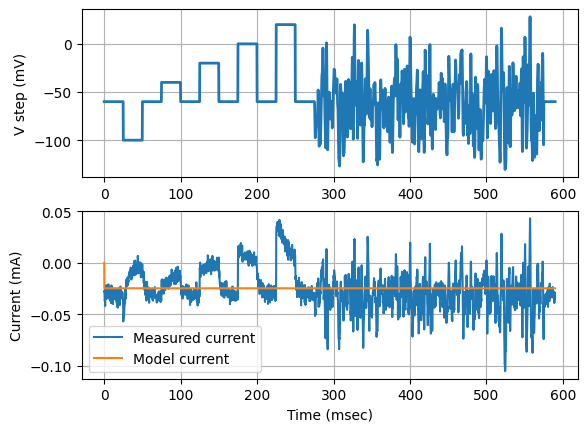

In [10]:
# %% SECTION 4: Function calls
if __name__ == "__main__":
    # Replace this with the path to the folder where provided input .txt file is!
    folder = "data"

    # Run function on the voltage-clamp data
    i = run_vclamp_model(folder)